# Credit Risk Modelling Under Assymetric Loss
### German Credit Dataset | Group 3

**Improvements over baseline:**
1. Added Random Forest with comparison
2. Cost function sensitivity analysis (justified, not hardcoded)
3. Class imbalance handling with SMOTE
4. Precision-Recall AUC (more honest for imbalanced data)
5. SHAP values for business interpretability
6. Calibration curves (probability trustworthiness)
7. Full model comparison table on business cost metric

## Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# For class imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# For explainability
import shap

print('All imports successful')

All imports successful


## 1. Data Loading & Preprocessing

In [2]:
df = pd.read_csv('data/german.data', sep=' ', header=None)

columns = [
    'checking_account', 'duration_months', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment_years', 'installment_rate',
    'personal_status_sex', 'other_debtors', 'residence_years', 'property', 'age',
    'other_installment_plans', 'housing', 'existing_credits', 'job',
    'num_dependents', 'telephone', 'foreign_worker', 'target'
]
df.columns = columns

# Remap: 1=Good→0, 2=Bad/Default→1
df['target'] = df['target'].map({1: 0, 2: 1})

print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:')
print(df['target'].value_counts())
print(f'\nDefault rate: {df["target"].mean():.1%}')
df.head()

Dataset shape: (1000, 21)

Class distribution:
target
0    700
1    300
Name: count, dtype: int64

Default rate: 30.0%


,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_years,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [3]:
X = df.drop('target', axis=1)
y = df['target']

numeric_features = [
    'duration_months', 'credit_amount', 'installment_rate',
    'residence_years', 'age', 'existing_credits', 'num_dependents'
]
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'Numeric features: {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')

Numeric features: 7
Categorical features: 13


## 2. Cost Function

The German Credit dataset documentation explicitly states that the cost of misclassifying a bad customer as good (False Negative) is **5× worse** than misclassifying a good customer as bad (False Positive).

- **FN cost = 5**: Bank loses the entire loan amount when a defaulter is approved
- **FP cost = 1**: Bank loses only potential interest when a good customer is rejected

We also run a **sensitivity analysis** to show the threshold is data-driven, not a magic number.

In [4]:
COST_FN = 5  # False Negative: missed defaulter (dataset-specified)
COST_FP = 1  # False Positive: rejected good customer

def compute_cost(y_true, y_pred, fn_cost=COST_FN, fp_cost=COST_FP):
    """Compute total financial cost from confusion matrix."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * fn_cost + fp * fp_cost

def find_optimal_threshold(y_true, y_prob, fn_cost=COST_FN, fp_cost=COST_FP):
    """Sweep thresholds 0→1 and return the one minimising total cost."""
    thresholds = np.linspace(0.01, 0.99, 200)
    costs = [
        compute_cost(y_true, (y_prob >= t).astype(int), fn_cost, fp_cost)
        for t in thresholds
    ]
    best_idx = np.argmin(costs)
    return thresholds[best_idx], costs[best_idx], thresholds, costs

print(f'Cost configuration: FN={COST_FN}, FP={COST_FP}')
print(f'Source: UCI German Credit dataset documentation')

Cost configuration: FN=5, FP=1
Source: UCI German Credit dataset documentation


## 3. Model Pipelines
### 3a. Logistic Regression (Baseline)

In [5]:
lr_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Cross-validation ROC-AUC (original metric)
lr_roc_cv = cross_val_score(lr_pipeline, X, y, cv=skf, scoring='roc_auc')
print(f'LR ROC-AUC (5-fold): {lr_roc_cv.mean():.3f} ± {lr_roc_cv.std():.3f}')

LR ROC-AUC (5-fold): 0.786 ± 0.020


### 3b. Random Forest (New Model)

In [6]:
rf_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',  # handles mild class imbalance natively
        random_state=42
    ))
])

rf_roc_cv = cross_val_score(rf_pipeline, X, y, cv=skf, scoring='roc_auc')
print(f'RF ROC-AUC (5-fold): {rf_roc_cv.mean():.3f} ± {rf_roc_cv.std():.3f}')

RF ROC-AUC (5-fold): 0.774 ± 0.029


## 4. Class Imbalance Handling — SMOTE

The dataset has 700 good vs 300 default customers (70/30 split). While not extreme, this imbalance can bias models toward the majority class. We use **SMOTE** (Synthetic Minority Over-sampling Technique) to create synthetic minority samples during training only (applied inside cross-validation to prevent data leakage).

In [7]:
# SMOTE is applied INSIDE the cross-validation fold to prevent data leakage
lr_smote_pipeline = ImbPipeline([
    ('pre', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

rf_smote_pipeline = ImbPipeline([
    ('pre', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

lr_s_roc_cv = cross_val_score(lr_smote_pipeline, X, y, cv=skf, scoring='roc_auc')
rf_s_roc_cv = cross_val_score(rf_smote_pipeline, X, y, cv=skf, scoring='roc_auc')

print(f'LR + SMOTE ROC-AUC: {lr_s_roc_cv.mean():.3f} ± {lr_s_roc_cv.std():.3f}')
print(f'RF + SMOTE ROC-AUC: {rf_s_roc_cv.mean():.3f} ± {rf_s_roc_cv.std():.3f}')

LR + SMOTE ROC-AUC: 0.781 ± 0.016
RF + SMOTE ROC-AUC: 0.771 ± 0.028


## 5. Generate Predicted Probabilities (All 4 Models)

In [8]:
print('Generating cross-validated probabilities for all models...')

lr_prob   = cross_val_predict(lr_pipeline,       X, y, cv=skf, method='predict_proba')[:, 1]
rf_prob   = cross_val_predict(rf_pipeline,       X, y, cv=skf, method='predict_proba')[:, 1]
lr_s_prob = cross_val_predict(lr_smote_pipeline, X, y, cv=skf, method='predict_proba')[:, 1]
rf_s_prob = cross_val_predict(rf_smote_pipeline, X, y, cv=skf, method='predict_proba')[:, 1]

# Find optimal thresholds for all
lr_opt_t,   lr_opt_cost,   lr_thresh,   lr_costs   = find_optimal_threshold(y, lr_prob)
rf_opt_t,   rf_opt_cost,   rf_thresh,   rf_costs   = find_optimal_threshold(y, rf_prob)
lr_s_opt_t, lr_s_opt_cost, lr_s_thresh, lr_s_costs = find_optimal_threshold(y, lr_s_prob)
rf_s_opt_t, rf_s_opt_cost, rf_s_thresh, rf_s_costs = find_optimal_threshold(y, rf_s_prob)

lr_default_cost   = compute_cost(y, (lr_prob   >= 0.5).astype(int))
rf_default_cost   = compute_cost(y, (rf_prob   >= 0.5).astype(int))
lr_s_default_cost = compute_cost(y, (lr_s_prob >= 0.5).astype(int))
rf_s_default_cost = compute_cost(y, (rf_s_prob >= 0.5).astype(int))

print('Done!')

Generating cross-validated probabilities for all models...
Done!


## 6. Visualisations
### Fig 1 - Class Distribution & Cost Sensitivity Analysis

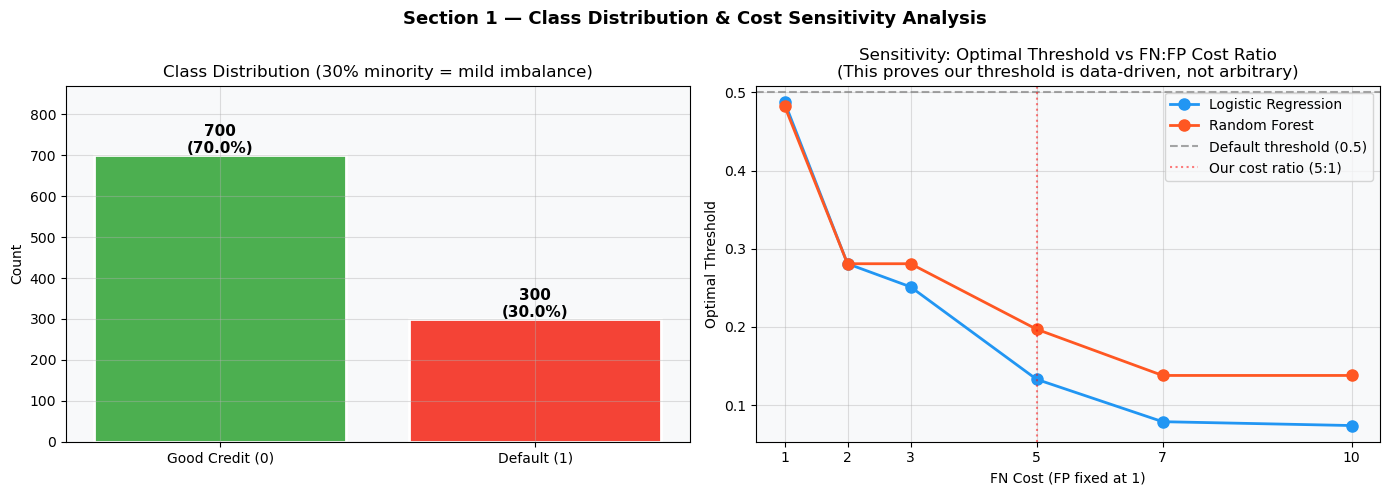

In [9]:
COLORS = {'lr': '#2196F3', 'rf': '#FF5722', 'ls': '#4CAF50', 'rs': '#9C27B0'}
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
                     'axes.grid': True, 'grid.alpha': 0.4})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 1 — Class Distribution & Cost Sensitivity Analysis',
             fontsize=13, fontweight='bold')

# Class distribution
ax = axes[0]
vals = [np.sum(y == 0), np.sum(y == 1)]
bars = ax.bar(['Good Credit (0)', 'Default (1)'], vals,
              color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=2)
for bar, cnt in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{cnt}\n({cnt/len(y)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Class Distribution (30% minority = mild imbalance)')
ax.set_ylabel('Count')
ax.set_ylim(0, 870)

# Sensitivity: how optimal threshold changes with cost ratio
ax = axes[1]
ratios = [1, 2, 3, 5, 7, 10]
for prob, lbl, c in [(lr_prob, 'Logistic Regression', COLORS['lr']),
                      (rf_prob, 'Random Forest', COLORS['rf'])]:
    opts = [find_optimal_threshold(y, prob, fn_cost=r)[0] for r in ratios]
    ax.plot(ratios, opts, marker='o', label=lbl, color=c, linewidth=2, markersize=8)

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
ax.axvline(5, color='red', linestyle=':', alpha=0.5, label='Our cost ratio (5:1)')
ax.set_title('Sensitivity: Optimal Threshold vs FN:FP Cost Ratio\n'
             '(This proves our threshold is data-driven, not arbitrary)')
ax.set_xlabel('FN Cost (FP fixed at 1)')
ax.set_ylabel('Optimal Threshold')
ax.legend()
ax.set_xticks(ratios)

plt.tight_layout()
plt.show()

### Fig 2 - ROC-AUC Curves (All 4 Models)

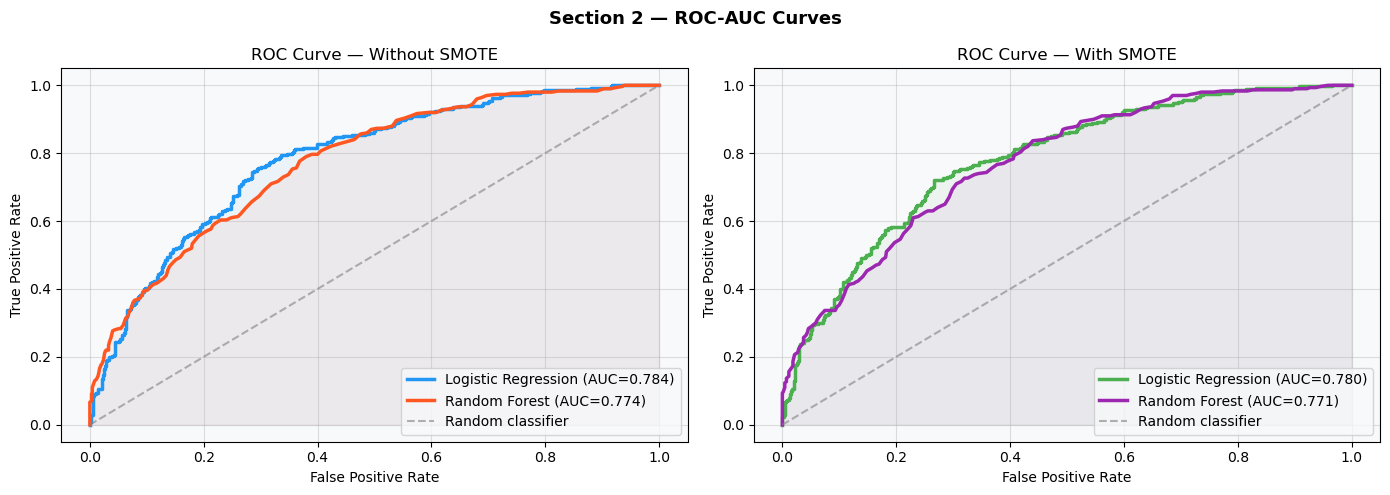

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 2 — ROC-AUC Curves', fontsize=13, fontweight='bold')

for ax, (pa, pb, ca, cb, title) in zip(axes, [
    (lr_prob, rf_prob, COLORS['lr'], COLORS['rf'], 'Without SMOTE'),
    (lr_s_prob, rf_s_prob, COLORS['ls'], COLORS['rs'], 'With SMOTE')
]):
    for prob, lbl, c in [(pa, 'Logistic Regression', ca), (pb, 'Random Forest', cb)]:
        fpr, tpr, _ = roc_curve(y, prob)
        auc = roc_auc_score(y, prob)
        ax.plot(fpr, tpr, color=c, linewidth=2.5, label=f'{lbl} (AUC={auc:.3f})')
        ax.fill_between(fpr, tpr, alpha=0.06, color=c)
    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6, label='Random classifier')
    ax.set_title(f'ROC Curve — {title}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Fig 3 - Precision-Recall Curves

**Why PR-AUC matters here:** With class imbalance, ROC-AUC can be misleadingly optimistic because it includes True Negatives in its calculation. PR-AUC focuses only on the minority class (defaulters), which is what we actually care about. A model that looks good on ROC can look much worse on PR — that gap reveals the truth.

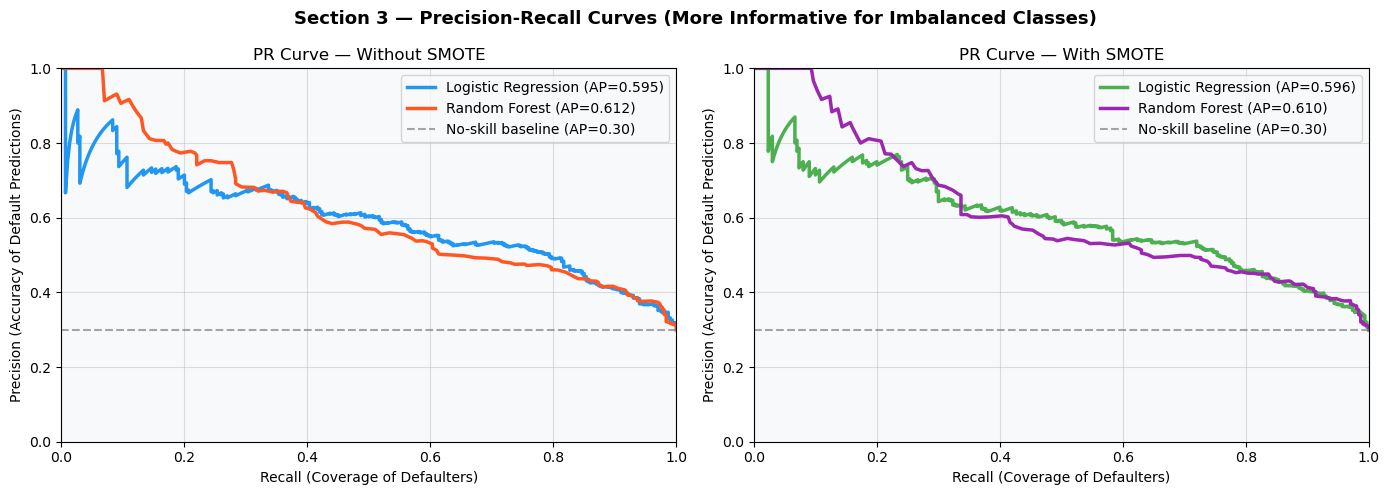

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 3 — Precision-Recall Curves (More Informative for Imbalanced Classes)',
             fontsize=13, fontweight='bold')

baseline = y.mean()  # no-skill AP = class prevalence
for ax, (pa, pb, ca, cb, title) in zip(axes, [
    (lr_prob, rf_prob, COLORS['lr'], COLORS['rf'], 'Without SMOTE'),
    (lr_s_prob, rf_s_prob, COLORS['ls'], COLORS['rs'], 'With SMOTE')
]):
    for prob, lbl, c in [(pa, 'Logistic Regression', ca), (pb, 'Random Forest', cb)]:
        prec, rec, _ = precision_recall_curve(y, prob)
        ap = average_precision_score(y, prob)
        ax.plot(rec, prec, color=c, linewidth=2.5, label=f'{lbl} (AP={ap:.3f})')
    ax.axhline(baseline, color='gray', linestyle='--', alpha=0.7,
               label=f'No-skill baseline (AP={baseline:.2f})')
    ax.set_title(f'PR Curve — {title}')
    ax.set_xlabel('Recall (Coverage of Defaulters)')
    ax.set_ylabel('Precision (Accuracy of Default Predictions)')
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

### Fig 4 - Financial Cost vs Decision Threshold

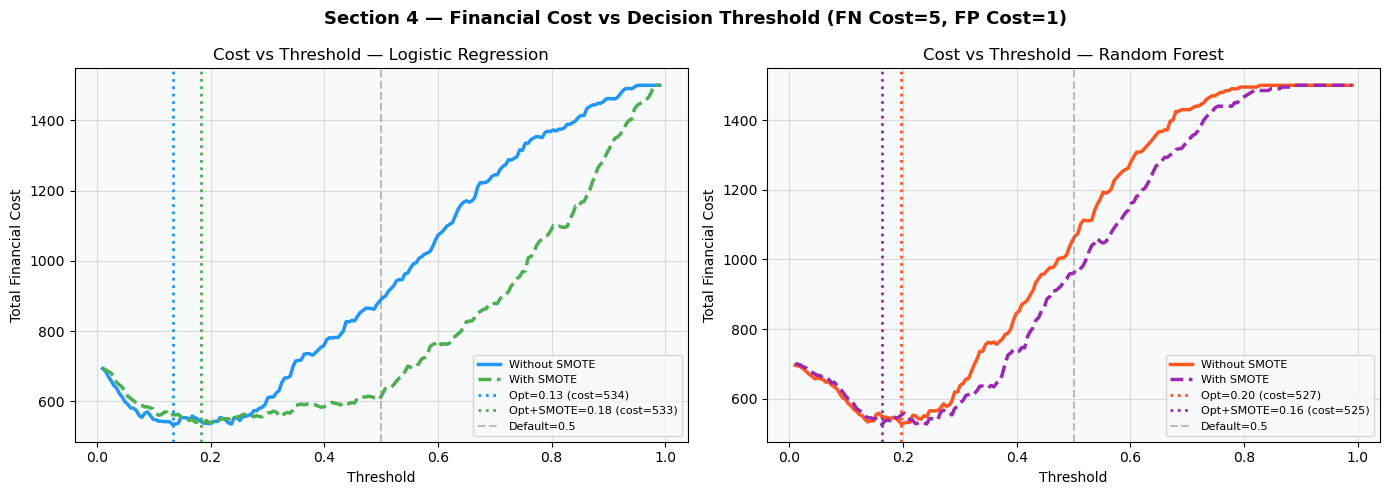

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 4 — Financial Cost vs Decision Threshold (FN Cost=5, FP Cost=1)',
             fontsize=13, fontweight='bold')

for ax, (t1, c1, ot1, oc1, t2, c2, ot2, oc2, lbl, cn, cs) in zip(axes, [
    (lr_thresh, lr_costs, lr_opt_t, lr_opt_cost,
     lr_s_thresh, lr_s_costs, lr_s_opt_t, lr_s_opt_cost,
     'Logistic Regression', COLORS['lr'], COLORS['ls']),
    (rf_thresh, rf_costs, rf_opt_t, rf_opt_cost,
     rf_s_thresh, rf_s_costs, rf_s_opt_t, rf_s_opt_cost,
     'Random Forest', COLORS['rf'], COLORS['rs'])
]):
    ax.plot(t1, c1, color=cn, linewidth=2.5, label='Without SMOTE')
    ax.plot(t2, c2, color=cs, linewidth=2.5, linestyle='--', label='With SMOTE')
    ax.axvline(ot1, color=cn, linestyle=':', linewidth=2,
               label=f'Opt={ot1:.2f} (cost={oc1})')
    ax.axvline(ot2, color=cs, linestyle=':', linewidth=2,
               label=f'Opt+SMOTE={ot2:.2f} (cost={oc2})')
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default=0.5')
    ax.set_title(f'Cost vs Threshold — {lbl}')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Total Financial Cost')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Fig 5 - Confusion Matrices at Optimal Thresholds

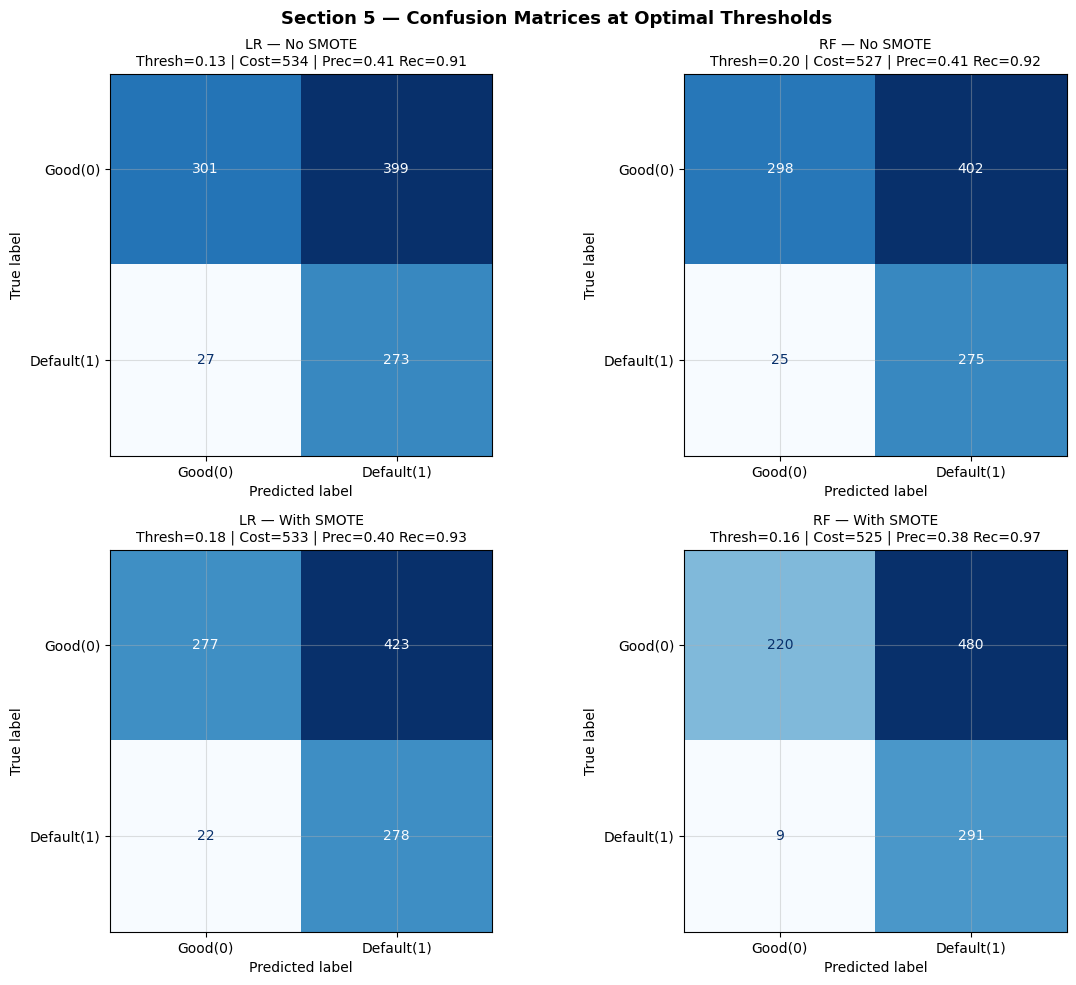

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Section 5 — Confusion Matrices at Optimal Thresholds',
             fontsize=13, fontweight='bold')

for prob, thresh, title, ax in [
    (lr_prob,   lr_opt_t,   'LR — No SMOTE',   axes[0, 0]),
    (rf_prob,   rf_opt_t,   'RF — No SMOTE',   axes[0, 1]),
    (lr_s_prob, lr_s_opt_t, 'LR — With SMOTE', axes[1, 0]),
    (rf_s_prob, rf_s_opt_t, 'RF — With SMOTE', axes[1, 1])
]:
    y_pred = (prob >= thresh).astype(int)
    cm = confusion_matrix(y, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Good(0)', 'Default(1)']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    tn, fp, fn, tp = cm.ravel()
    cost = fn * 5 + fp * 1
    ax.set_title(
        f'{title}\nThresh={thresh:.2f} | Cost={cost} '
        f'| Prec={precision_score(y, y_pred):.2f} '
        f'Rec={recall_score(y, y_pred):.2f}',
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Fig 6 - Calibration Curves

**What this shows:** A calibration curve tells us whether the model's predicted probabilities are reliable. If the model says '70% chance of default', does default actually happen 70% of the time?

- A perfectly calibrated model follows the diagonal
- **Logistic Regression** is typically well-calibrated by design
- **Random Forest** tends to push probabilities toward extremes (overconfident)

This matters because our threshold optimisation depends on the probabilities being meaningful.

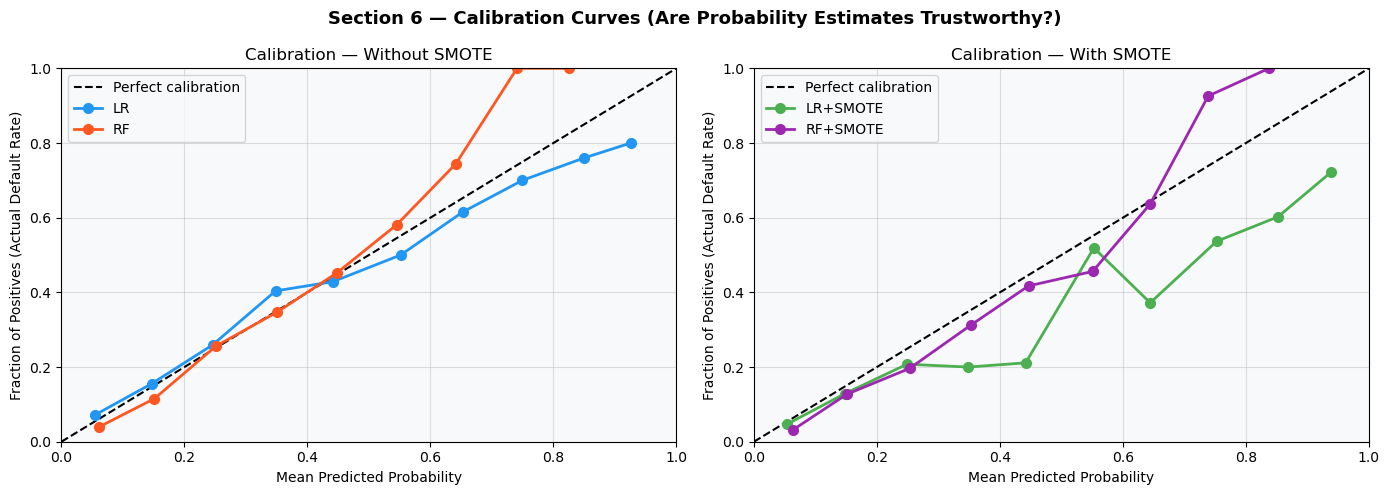

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 6 — Calibration Curves (Are Probability Estimates Trustworthy?)',
             fontsize=13, fontweight='bold')

for ax, (probs, labels, colors, title) in zip(axes, [
    ([lr_prob, rf_prob], ['LR', 'RF'], [COLORS['lr'], COLORS['rf']], 'Without SMOTE'),
    ([lr_s_prob, rf_s_prob], ['LR+SMOTE', 'RF+SMOTE'],
     [COLORS['ls'], COLORS['rs']], 'With SMOTE')
]):
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=1.5)
    for prob, lbl, c in zip(probs, labels, colors):
        frac_pos, mean_pred = calibration_curve(y, prob, n_bins=10)
        ax.plot(mean_pred, frac_pos, marker='o', color=c,
                linewidth=2, markersize=7, label=lbl)
    ax.set_title(f'Calibration — {title}')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives (Actual Default Rate)')
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

### Fig 7 - SHAP Feature Importance (Business Interpretability)

**Why SHAP over standard feature importance?**
- Standard importance only tells you *which* features matter
- SHAP tells you *how* each feature value affects the prediction direction
- This is required in real credit risk (regulators need explanations for loan rejections)
- SHAP is model-agnostic and individually explainable per customer

In [16]:
# Train RF on full dataset for SHAP (interpretability, not generalisation)
rf_for_shap = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
])
rf_for_shap.fit(X, y)

X_transformed = rf_for_shap.named_steps['pre'].transform(X)
ohe = rf_for_shap.named_steps['pre'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(categorical_features).tolist()
feature_names = numeric_features + cat_names

explainer = shap.TreeExplainer(rf_for_shap.named_steps['clf'])
shap_vals = explainer.shap_values(X_transformed)
sv1 = shap_vals[:, :, 1] if np.array(shap_vals).ndim == 3 else shap_vals[1]

print(f'SHAP computed for {sv1.shape[0]} customers across {sv1.shape[1]} features')

SHAP computed for 1000 customers across 48 features


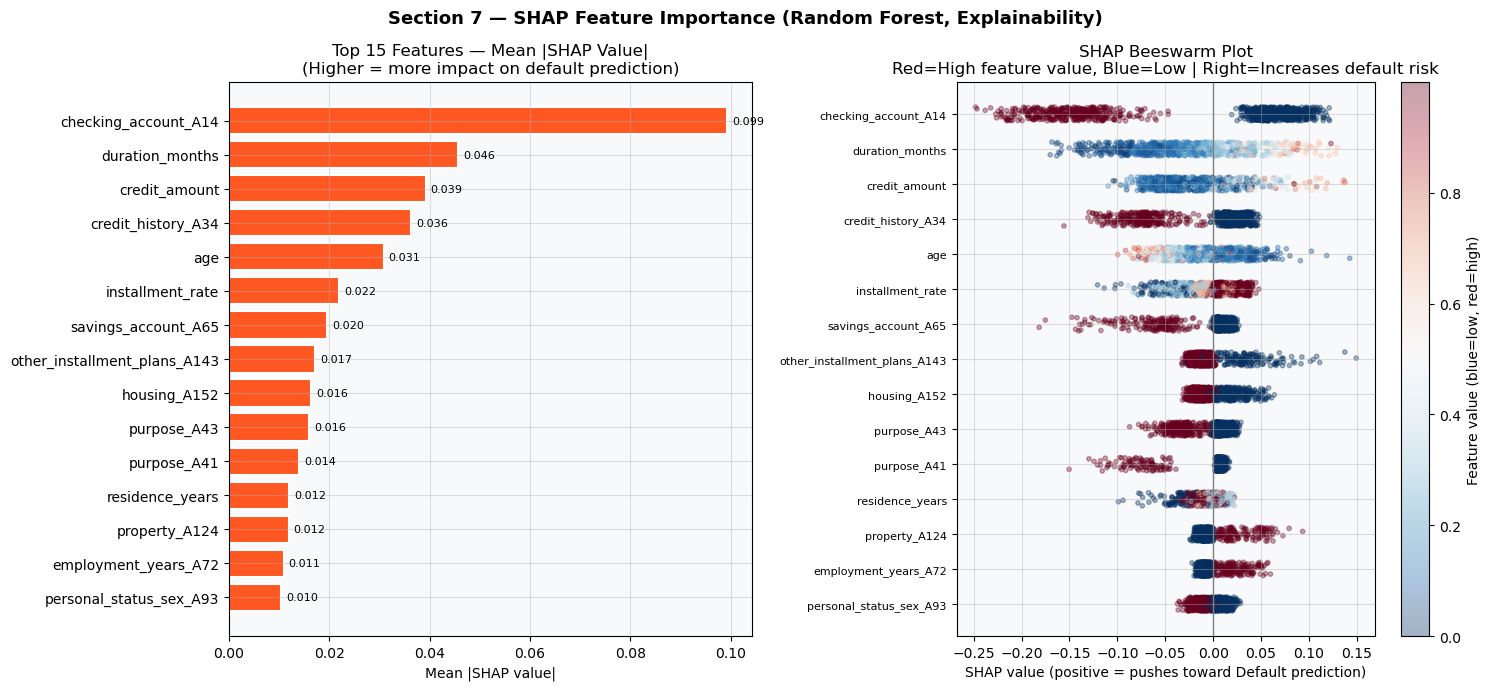

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Section 7 — SHAP Feature Importance (Random Forest, Explainability)',
             fontsize=13, fontweight='bold')

mean_shap = np.abs(sv1).mean(axis=0)
idx15 = np.argsort(mean_shap)[-15:]

# Bar chart
ax = axes[0]
ax.barh(np.array(feature_names)[idx15], mean_shap[idx15],
        color='#FF5722', edgecolor='white', linewidth=1.5)
ax.set_title('Top 15 Features — Mean |SHAP Value|\n'
             '(Higher = more impact on default prediction)')
ax.set_xlabel('Mean |SHAP value|')
for i, (name, val) in enumerate(zip(np.array(feature_names)[idx15], mean_shap[idx15])):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)

# Beeswarm plot
ax = axes[1]
np.random.seed(42)
for i, fi in enumerate(idx15):
    sv_col = sv1[:, fi]
    feat_col = X_transformed[:, fi]
    norm = (feat_col - feat_col.min()) / (feat_col.max() - feat_col.min() + 1e-9)
    jitter = np.random.uniform(-0.2, 0.2, size=len(sv_col))
    sc = ax.scatter(sv_col, np.full(len(sv_col), i) + jitter,
                    c=norm, cmap='RdBu_r', alpha=0.35, s=10)

ax.set_yticks(range(15))
ax.set_yticklabels(np.array(feature_names)[idx15], fontsize=8)
ax.axvline(0, color='gray', linewidth=1)
ax.set_title('SHAP Beeswarm Plot\nRed=High feature value, Blue=Low | '
             'Right=Increases default risk')
ax.set_xlabel('SHAP value (positive = pushes toward Default prediction)')
plt.colorbar(sc, ax=ax, label='Feature value (blue=low, red=high)')

plt.tight_layout()
plt.show()

## 8. Final Model Comparison Table

All models compared on **business-relevant metrics**, not just accuracy.
The yellow row indicates the model with the lowest financial cost at its optimal threshold.

In [18]:
results = []
for prob, opt_t, dc, oc, label in [
    (lr_prob,   lr_opt_t,   lr_default_cost,   lr_opt_cost,   'LR'),
    (rf_prob,   rf_opt_t,   rf_default_cost,   rf_opt_cost,   'RF'),
    (lr_s_prob, lr_s_opt_t, lr_s_default_cost, lr_s_opt_cost, 'LR + SMOTE'),
    (rf_s_prob, rf_s_opt_t, rf_s_default_cost, rf_s_opt_cost, 'RF + SMOTE'),
]:
    y_opt = (prob >= opt_t).astype(int)
    results.append({
        'Model':            label,
        'ROC-AUC':          round(roc_auc_score(y, prob), 3),
        'PR-AUC':           round(average_precision_score(y, prob), 3),
        'Opt Threshold':    round(opt_t, 2),
        'Cost @ 0.5':       dc,
        'Cost @ Opt':       oc,
        'Cost Saving':      f'{(dc - oc) / dc * 100:.1f}%',
        'Precision @ Opt':  round(precision_score(y, y_opt), 3),
        'Recall @ Opt':     round(recall_score(y, y_opt), 3),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

     Model  ROC-AUC  PR-AUC  Opt Threshold  Cost @ 0.5  Cost @ Opt Cost Saving  Precision @ Opt  Recall @ Opt
        LR    0.784   0.595           0.13         890         534       40.0%            0.406         0.910
        RF    0.774   0.612           0.20        1053         527       50.0%            0.406         0.917
LR + SMOTE    0.780   0.596           0.18         606         533       12.0%            0.397         0.927
RF + SMOTE    0.771   0.610           0.16         960         525       45.3%            0.377         0.970


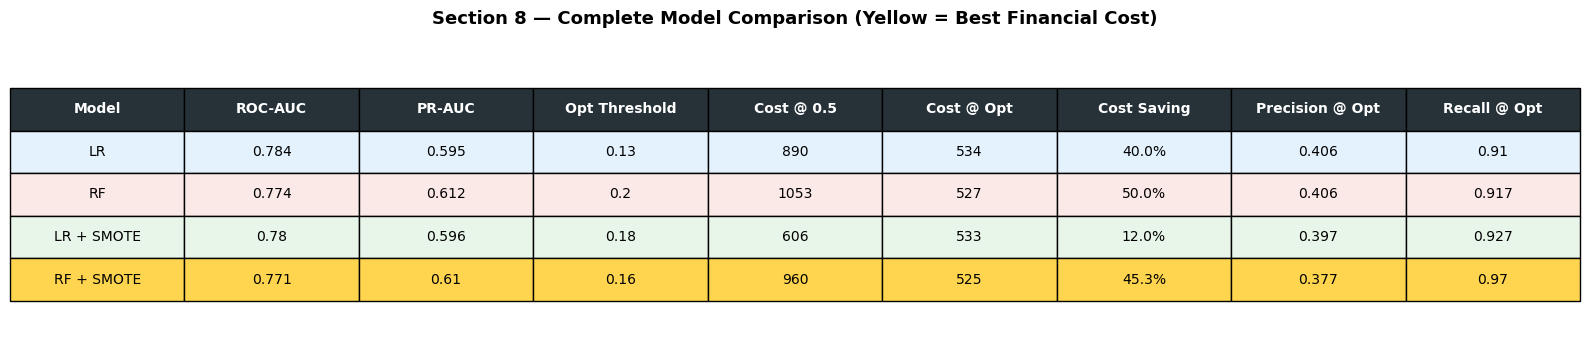

In [19]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(16, 3.5))
fig.suptitle('Section 8 — Complete Model Comparison (Yellow = Best Financial Cost)',
             fontsize=13, fontweight='bold')
ax.axis('off')

tbl = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.4)

# Header
for j in range(len(results_df.columns)):
    tbl[0, j].set_facecolor('#263238')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Row colours
row_colors = ['#E3F2FD', '#FBE9E7', '#E8F5E9', '#F3E5F5']
best_row = pd.Series([r['Cost @ Opt'] for r in results]).idxmin() + 1
for i in range(1, 5):
    for j in range(len(results_df.columns)):
        tbl[i, j].set_facecolor(row_colors[i - 1])

# Highlight winner
for j in range(len(results_df.columns)):
    tbl[best_row, j].set_facecolor('#FFD54F')

plt.tight_layout()
plt.show()